Train the model.

In [1]:
import pickle
import pandas as pd
import KNN
import digitalization

data = pd.read_csv("original_data.csv")
digitalization.train(data)

KNN.KNN_model(factor_number=7,k=3,test_data_number=90)

Accuracy of the KNN Clasification is:  0.8444444444444444


Predict student's level one by one based on input value.

In [2]:
import one_by_one
import pandas as pd
import digitalization_one_by_one_new
one_by_one.KNN_one_by_one(test_data_number=90)

Please enter the value of k: 3
Please enter Admission_Channel: JUPAS
Please enter Secondary_School: CCC HEEP WOH COLLEGE
Please enter Exam: HKDSE
Please enter Math_Background: 5
Please enter MATH1510: A
Please enter ENGG1130: A
predict level is ['A']


Predict all students' level at one time.

In [3]:
df = pd.read_csv("data_to_predict.csv")
dataset = df.drop(['ENGG2020'],axis=1)
digitalization.predict(dataset)

X = dataset.iloc[:,1:7].values
# print(X)

# Load the KNN model
with open('KNN.pickle', 'rb') as model_file:
    KNN = pickle.load(model_file)

# Predicting the Test set results
y_pred = KNN.predict(X)
print('Number of predictions: ', len(y_pred))
knn_df=pd.DataFrame(y_pred)
knn_df.columns = ['ENGG2020']
pd.DataFrame(knn_df).to_csv('KNN_pred_level.csv',index=None)
f1 = pd.read_csv('predict_data.csv')
f2 = pd.read_csv('KNN_pred_level.csv')
file = [f1,f2]
train = pd.concat(file,axis=1)
train.to_csv("KNN_predict_complete" + ".csv", index=0, sep=',')

Number of predictions:  545


Show the relationships between the amount of training data and accuracy.
(Run the first program first)

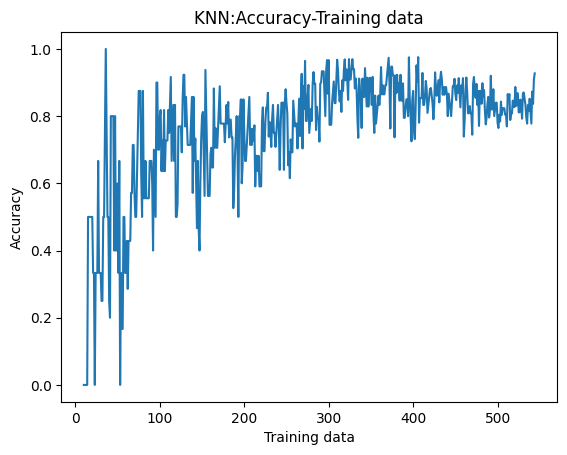

In [4]:
import KNN_Comparison
import matplotlib.pyplot as plt

dataset = pd.read_csv('train_data.csv')
sample_number=len(dataset)
a = []
b = []
for i in range(10,sample_number):
  a.append(i)
  b.append(KNN_Comparison.KNN_comparison(i,0.1,3))
plt.plot(a, b)
plt.xlabel("Training data")
plt.ylabel("Accuracy")
plt.title("KNN:Accuracy-Training data")
plt.show()

Show the relationships between the amount of test data and accuracy. (Run the first program first)

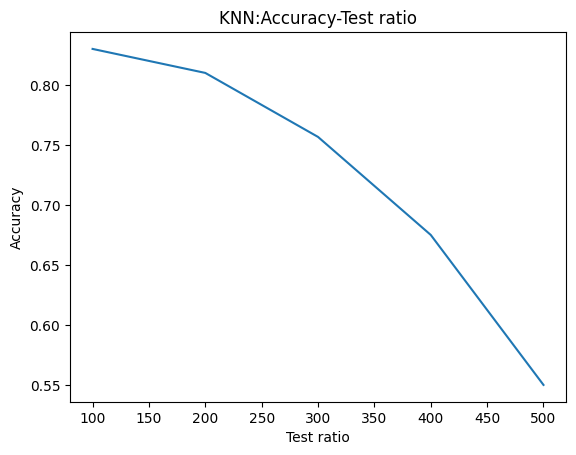

In [5]:
import KNN_Comparison
import matplotlib.pyplot as plt

dataset = pd.read_csv('train_data.csv')
sample_number=len(dataset)
c = []
d = []
for r in range(100,sample_number,100):
  c.append(r)
  d.append(KNN_Comparison.KNN_comparison(sample_number,r,3))
plt.plot(c, d)
plt.xlabel("Test ratio")
plt.ylabel("Accuracy")
plt.title("KNN:Accuracy-Test ratio")
plt.show()

Show the relationships between k and accuracy. (Run the first program first)

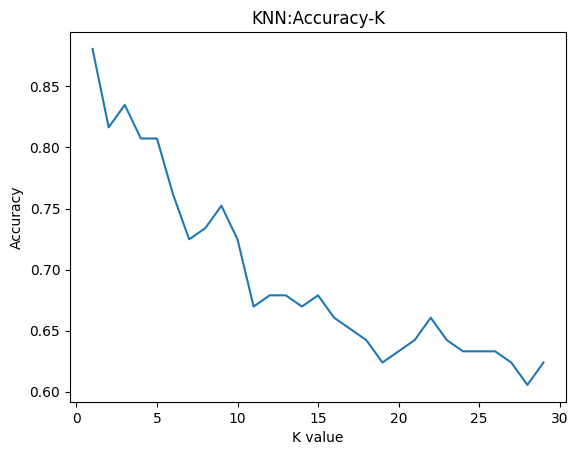

In [6]:
import KNN_Comparison
import matplotlib.pyplot as plt

dataset = pd.read_csv('train_data.csv')
sample_number=len(dataset)
e = []
f = []
for k in range(1,30):
  e.append(k)
  f.append(KNN_Comparison.KNN_comparison(sample_number,0.2,k))

max_accuracy = max(f)
best_k = e[f.index(max_accuracy)]
print(f"Highest accuracy: {max_accuracy}")
print(f"Best k value: {best_k}")

plt.plot(e, f)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN:Accuracy-K")
plt.show()

Try your own data (Run the top cell first)

The number of students means how many valid rows of students' information in your excel file.

In [7]:
import digitalization
df = pd.read_excel("Input information.xlsx")
df1 = df.drop(['School_Information','ENGG2020'],axis=1)
pd.DataFrame(df1).to_csv('Personal_Information.csv',index=None)
dataset = pd.read_csv("Personal_Information.csv")
digitalization.predict(dataset)
student_number = int(input('Please input the number of students: ',))
X = dataset.iloc[:student_number,1:7].values
# print(X)

# Load the KNN model
with open('KNN.pickle', 'rb') as model_file:
    KNN = pickle.load(model_file)

# Predicting the Test set results
y_pred = KNN.predict(X)
print('Number of predictions: ', len(y_pred))
print('Predict Level: ', y_pred)
knn_df=pd.DataFrame(y_pred)
knn_df.columns = ['ENGG2020']
pd.DataFrame(knn_df).to_csv('KNN_pred_level.csv',index=None)
f1 = pd.read_csv('predict_data.csv')
f2 = pd.read_csv('KNN_pred_level.csv')
file = [f1,f2]
train = pd.concat(file,axis=1)
train.to_csv("Personal_KNN_predict_complete" + ".csv", index=0, sep=',')

: 

If you want to add some extra columns of student features

In [8]:
import pickle
import pandas as pd
import KNN
import digitalization_more

data = pd.read_csv("original_data_with_more_columns.csv")
digitalization_more.train(data)

KNN.KNN_model(factor_number=9,k=3,test_data_number=90)

df1 = pd.read_csv("data_to_predict_with_more_columns.csv")
dataset = df1.drop(['ENGG2020'],axis=1)
digitalization_more.predict(dataset)

X = dataset.iloc[:,1:9].values
# print(X)

# Load the KNN model
with open('KNN.pickle', 'rb') as model_file:
    KNN = pickle.load(model_file)

# Predicting the Test set results
y_pred = KNN.predict(X)
print('Number of predictions: ', len(y_pred))
knn_df=pd.DataFrame(y_pred)
knn_df.columns = ['ENGG2020']
pd.DataFrame(knn_df).to_csv('KNN_pred_level.csv',index=None)
f1 = pd.read_csv('predict_data.csv')
f2 = pd.read_csv('KNN_pred_level.csv')
file = [f1,f2]
train = pd.concat(file,axis=1)
train.to_csv("More_KNN_predict_complete" + ".csv", index=0, sep=',')

Accuracy of the KNN Clasification is:  0.5888888888888889
Number of predictions:  545
